In [1]:
import numpy as np
from numpy import pi
from qiskit.circuit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Options, Session, Batch, SamplerV2 as Sampler, EstimatorV2 as Estimator
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram, plot_bloch_multivector

In [2]:
# For simulators - both local and real hardware
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
print(backend.name)

backend_sim = AerSimulator.from_backend(backend)

from qiskit.primitives import BackendSamplerV2
sampler_sim = BackendSamplerV2(backend = backend_sim)
from qiskit.primitives import BackendEstimatorV2
estimator_sim = BackendEstimatorV2(backend = backend_sim)

ibm_sherbrooke


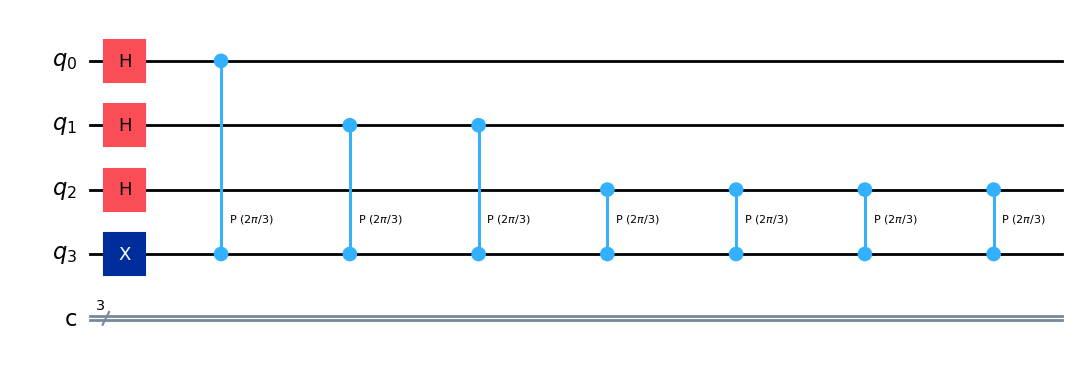

In [3]:
theta = 1/3

qpe = QuantumCircuit(4, 3)
qpe.x(3)
for qubit in range(3):
    qpe.h(qubit)
repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qpe.cp(2*pi*theta, counting_qubit, 3); # This is C-U
    repetitions *= 2
qpe.draw(output='mpl')

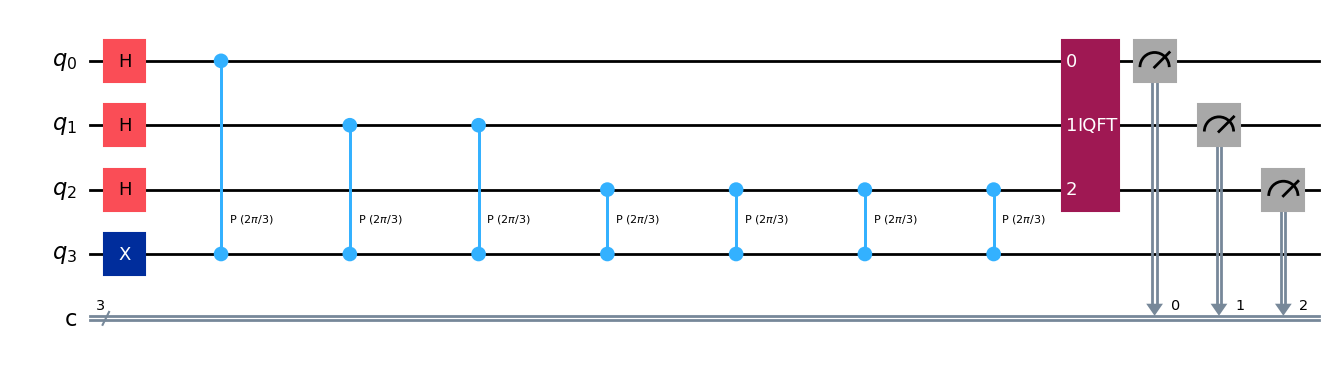

In [4]:
from qiskit.circuit.library import QFT
# Apply inverse QFT
qpe.append(QFT(3, inverse=True), [0,1,2])
qpe.draw(output='mpl')
for n in range(3):
    qpe.measure(n,n)
qpe.draw(output='mpl')

In [5]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_qpe = pm.run(qpe)

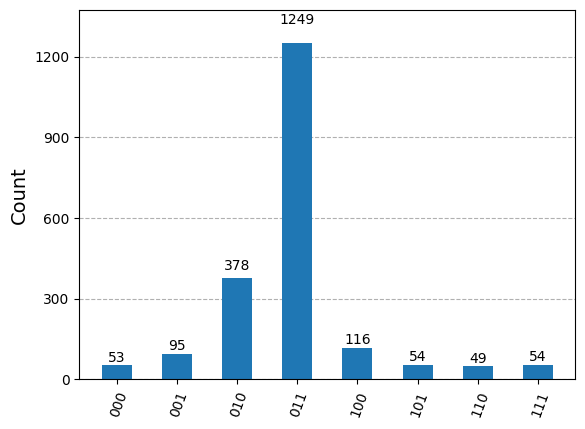

In [6]:
num_shots = 2048
sampler = Sampler(mode=backend_sim)
job = sampler.run([transpiled_qpe], shots = num_shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)